In [8]:
library(parallel)
library(Biostrings)
library(ape)


Attaching package: ‘ape’


The following object is masked from ‘package:Biostrings’:

    complement




In [9]:
metadata = read.delim("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv",header = T)
rownames(metadata) = metadata$assemblyID

envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_707Poaceae_20250804.txt")
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"
envDf$assemblyID = as.factor(envDf$assemblyID)

# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral_filtered_20250407.nwk")
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

commonID = Reduce("intersect",list(spTre.rooted$tip.label,rownames(envDf),metadata$assemblyID))
length(commonID)

[1] 687

In [3]:
dnaFastaPerOG = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/CDSMSAPerOG_gs",pattern = "*.gs.l0.fa$",
                                   full.names = T),function(x) readDNAStringSet(x),mc.cores = 20)

names(dnaFastaPerOG) = gsub(".gs.l0.fa","",list.files("/workdir/sh2246/p_phyloGWAS/output/CDSMSAPerOG_gs",pattern = "*.gs.l0.fa$"))

gc.og = mclapply(dnaFastaPerOG,function(x){
    tmp = letterFrequency(x,letters = c("A","T","C","G"))
    rownames(tmp) = names(x)
    tmp = apply(tmp,2,function(x) tapply(x,limma::strsplit2(rownames(tmp),":")[,2],sum))
    tmp.gc = rowSums(tmp[,3:4])/rowSums(tmp)
    return(tmp.gc[commonID])
},mc.cores = 30)

gc.og = simplify2array(gc.og)

Warning message in mclapply(dnaFastaPerOG, function(x) {:
“all scheduled cores encountered errors in user code”


In [6]:
head(gc.og)

OG0000062 
"Error in FUN(X[[i]], ...) : object 'commonID' not found\n" 
                                                  OG0000098 
"Error in FUN(X[[i]], ...) : object 'commonID' not found\n" 
                                                  OG0000106 
"Error in FUN(X[[i]], ...) : object 'commonID' not found\n" 
                                                  OG0000124 
"Error in FUN(X[[i]], ...) : object 'commonID' not found\n" 
                                                  OG0000150 
"Error in FUN(X[[i]], ...) : object 'commonID' not found\n" 
                                                  OG0000152 
"Error in FUN(X[[i]], ...) : object 'commonID' not found\n"

In [ ]:
fwrite(gc.og,"/workdir/sh2246/p_phyloGWAS/output/GCperOG_20250729.txt",sep = "\t",row.names = T,quote = F)

In [ ]:
gc.og = fread("/workdir/sh2246/p_phyloGWAS/output/GCperOG_20250729.txt",data.table = F,header = T)
rownames(gc.og) = gc.og[,1]
gc.og = as.matrix(gc.og[,-1])

In [ ]:
gc.og.avg = apply(gc.og,2,mean,na.rm = T)
gc.og.sd = apply(gc.og,2,sd,na.rm = T)

In [ ]:
options(repr.plot.width=10, repr.plot.height=8)
par(mfrow = c(1,2))
hist(gc.og.avg,breaks = seq(0.2,1,0.02),main = "avg. GC% per OG",xlab = "")
hist(gc.og.sd,breaks = seq(0,.3,0.01),main = "S.D. of GC% per OG",xlab = "")

In [ ]:
LSD::heatscatter(t(gc.og)[,1],t(gc.og)[,279],xlab = "wheat (Jagger)",ylab = "maize (B73)",main = "wheat vs. maize")
cor(t(gc.og)[,c(1,279)],use = "pairwise.complete.obs")

In [ ]:
LSD::heatscatter(t(gc.og)[,1],t(gc.og)[,120],xlab = "wheat (Jagger)",ylab = "Rice (Nipponbare)",main = "wheat vs. rice")
cor(t(gc.og)[,c(1,120)],use = "pairwise.complete.obs")

In [ ]:
gc.og.filled = gc.og
gc.og.filled[is.na(gc.og.filled)] = mean(gc.og,na.rm = T)

In [ ]:
### 4d

In [4]:
get_4fold_sites <- function(ref_seq) {
  codons <- substring(ref_seq, seq(1, nchar(ref_seq) - 2, by = 3), seq(3, nchar(ref_seq), by = 3))

  # Define all 4-fold degenerate codons
  codon_table_4fold <- c(
    "GCT","GCC","GCA","GCG",  # Ala
    "CGT","CGC","CGA","CGG",  # Arg
    "GGT","GGC","GGA","GGG",  # Gly
    "CCT","CCC","CCA","CCG",  # Pro
    "ACT","ACC","ACA","ACG",  # Thr
    "GTT","GTC","GTA","GTG",  # Val
    "TCT","TCC","TCA","TCG",  # Ser
    "CTT","CTC","CTA","CTG"   # Leu
  )

  is_4fold <- codons %in% codon_table_4fold
  third_base_indices <- which(is_4fold) * 3
  return(third_base_indices)
}


In [ ]:
dnaFastaPerOG4d = mclapply(dnaFastaPerOG,function(x) {
    gc()
    ref_seq = x[grep("ASM1935983v1",names(x))[1]]
    msa_mat = as.matrix(x)
    msa_mat_4d = msa_mat[,get_4fold_sites(ref_seq)]
    if(is.null(msa_mat_4d)) return(NULL)
    else{
        msa_seqs <- apply(msa_mat_4d, 1, paste0, collapse = "")

    # Convert back to DNAStringSet
    msa_dna <- DNAStringSet(msa_seqs)
    names(msa_dna) <- rownames(msa_mat)
    return(msa_dna)
    }
    
},mc.cores = 30)

dnaFastaPerOG4d = dnaFastaPerOG4d[sapply(dnaFastaPerOG4d,length)!=1]

gc.og.4d = mclapply(dnaFastaPerOG4d,function(x){
    tmp = letterFrequency(x,letters = c("A","T","C","G"))
    rownames(tmp) = names(x)
    tmp = apply(tmp,2,function(x) tapply(x,limma::strsplit2(rownames(tmp),":")[,2],sum))
    tmp = as.data.frame(tmp)
    tmp.gc = rowSums(tmp[,3:4])/rowSums(tmp)
    return(tmp.gc[commonID])
},mc.cores = 30)

gc.og.4d= simplify2array(gc.og.4d)

In [ ]:
dna.comp.og.4d = mclapply(dnaFastaPerOG4d,function(x){
    tmp = letterFrequency(x,letters = c("A","T","C","G"))
    rownames(tmp) = names(x)
    tmp = apply(tmp,2,function(x) tapply(x,limma::strsplit2(rownames(tmp),":")[,2],sum))
    tmp = as.data.frame(tmp)
    return(tmp[commonID,])
},mc.cores = 30)



In [ ]:
options(repr.plot.width=8, repr.plot.height=8)
hist(gc.og.4d[279,],breaks = seq(0,1,0.02),main = "GC% at 4-fold degenerate site per OG in Maize (B73)",xlab = "")

In [ ]:
LSD::heatscatter(t(gc.og)[colnames(gc.og.4d),279],t(gc.og.4d)[,279],
                 xlab = "all coding sites",ylab = "4-fold degenerate site",main = "maize (B73)")
abline(a=0,b=1)

In [ ]:
gc.og.4d.avg = apply(gc.og.4d,2,mean,na.rm = T)
gc.og.4d.sd = apply(gc.og.4d,2,sd,na.rm = T)

In [ ]:
hist(gc.og.4d.avg,breaks = seq(0,1,0.02),main = "avg. GC% at 4d site per OG",xlab = "")

In [ ]:
LSD::heatscatter(t(gc.og.4d)[,279],t(gc.og.4d)[,120],
                 xlab = "Maize (B73)",ylab = "Rice (Nipponbare)",main = "maize vs. rice")
abline(a=0,b=1)
cor(t(gc.og.4d)[,c(279,120)],use = "pairwise.complete.obs")

In [81]:
dnaFastaPerOG4d50 = mclapply(dnaFastaPerOG,function(x) {
    tryCatch(
        {
        gc()
        ref_seq = x[grep("ASM1935983v1",names(x))[1]]
        msa_mat = as.matrix(x)
        Idx4d = get_4fold_sites(ref_seq)
        if (width(ref_seq)>150) Idx4d = Idx4d[Idx4d<150]
        if(length(Idx4d)!=0) {
            msa_mat_4d = msa_mat[,Idx4d,drop = F]
            msa_seqs <- apply(msa_mat_4d, 1, paste0, collapse = "")

        # Convert back to DNAStringSet
        msa_dna <- DNAStringSet(msa_seqs)
        names(msa_dna) <- rownames(msa_mat)
        return(msa_dna)
        } else return(NULL)
    },error = NULL)
},mc.cores = 40)

In [86]:
dnaFastaPerOG4d50[11]

$OG0000202
DNAStringSet object of length 1196:
       width seq                                            names               
   [1]    28 GGGGGGCCCGGCGGCGCCCGGGCGGACC                   OG0000202:10wheat...
   [2]    28 GGGGGGCCCGGCGGCGCCCCGGCGCGCC                   OG0000202:10wheat...
   [3]    28 GCGGGGCCCGGCGGCGCCCGGGGGGGGG                   OG0000202:10wheat...
   [4]    28 GGGGGGCCCGGCGGCGCCCCGGCGCGCC                   OG0000202:10wheat...
   [5]    28 GGGGGGCCCGGCGGCGCCCGGGCGGACC                   OG0000202:10wheat...
   ...   ... ...
[1192]    28 GGGGGGCCCGGCGGGGACCGAGCAGGCC                   OG0000202:lpTucGr...
[1193]    28 GGGGAGGGCTGCGGGATCGGGGCAGGTT                   OG0000202:mabambo...
[1194]    28 GGGGAGGGCTGCGGGATCGGGGCAGGTT                   OG0000202:mabambo...
[1195]    28 GGGGAGGATTGCGGGGTCAGGACAGGTT                   OG0000202:mabambo...
[1196]    28 GGGGGCCCCGGCGCGGCCCGGGCCGGCC                   OG0000202:pearl_m...


In [87]:
dnaFastaPerOG4d50 = dnaFastaPerOG4d50[!sapply(dnaFastaPerOG4d50,function(x) length(x)==1)]

gc.og.4d.50 = mclapply(dnaFastaPerOG4d50,function(x){
    tmp = letterFrequency(x,letters = c("A","T","C","G"))
    rownames(tmp) = names(x)
    tmp = apply(tmp,2,function(x) tapply(x,limma::strsplit2(rownames(tmp),":")[,2],sum,na.rm = T))
    tmp = as.data.frame(tmp)
    tmp.gc = rowSums(tmp[,3:4])/rowSums(tmp)
    return(tmp.gc[commonID])
},mc.cores = 30)

gc.og.4d.50= simplify2array(gc.og.4d.50)

In [88]:
data.table::fwrite(gc.og.4d.50,"/workdir/sh2246/p_phyloGWAS/output/GCperOG_4dfirst150bp_20251125.txt",
       sep = "\t",row.names = T,quote = F)

x being coerced from class: matrix to data.table



In [21]:
length(dnaFastaPerOG)

[1] 20434

In [66]:
ref_seq = dnaFastaPerOG[["OG0001399"]][grep("ASM1935983v1",names(dnaFastaPerOG[["OG0001399"]]))[1]]

In [ ]:
dnaFastaPerOG4d50up = mclapply(dnaFastaPerOG,function(x) {
    gc()
    ref_seq = x[grep("ASM1935983v1",names(x))[1]]
    msa_mat = as.matrix(x)
    Idx4d = get_4fold_sites(ref_seq)
    if(width(ref_seq)>150) Idx4d = Idx4d[Idx4d>150] else{Idx4d=NULL}
    msa_mat_4d = msa_mat[,Idx4d]
    if(length(Idx4d)!=0){
        msa_seqs <- apply(msa_mat_4d, 1, paste0, collapse = "")
        msa_dna <- DNAStringSet(msa_seqs)
        names(msa_dna) <- rownames(msa_mat)
        return(msa_dna)
    } else return(NULL)
},mc.cores = 30)

dnaFastaPerOG4d50up = dnaFastaPerOG4d50up[!sapply(dnaFastaPerOG4d50up,is.null)]

gc.og.4d.50up = mclapply(dnaFastaPerOG4d50up,function(x){
    tmp = letterFrequency(x,letters = c("A","T","C","G"))
    rownames(tmp) = names(x)
    tmp = apply(tmp,2,function(x) tapply(x,limma::strsplit2(rownames(tmp),":")[,2],sum))
    tmp = as.data.frame(tmp)
    tmp.gc = rowSums(tmp[,3:4])/rowSums(tmp)
    return(tmp.gc[commonID])
},mc.cores = 30)

gc.og.4d.50up= simplify2array(gc.og.4d.50up)

In [89]:
gc.og.4d.50.avg = apply(gc.og.4d.50,2,mean,na.rm = T)

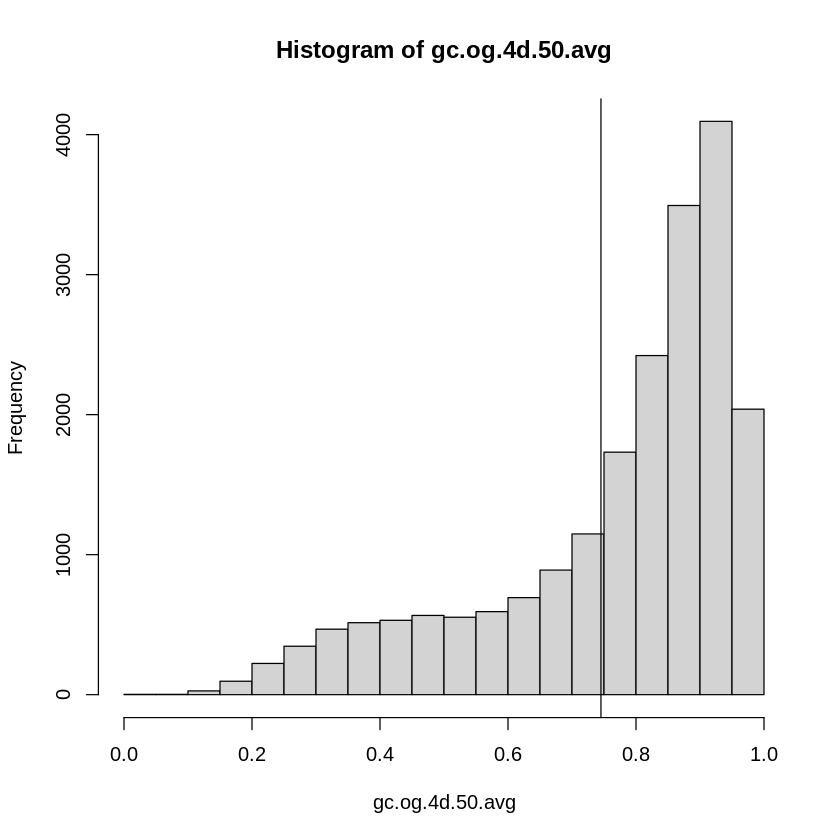

In [90]:
hist(gc.og.4d.50.avg)
abline(v = gc.og.4d.50.avg["OG0018915"])

In [27]:
head(gc.og.4d.50.avg["OG0018915"])

OG0018915 
0.7452432

In [ ]:
LSD::heatscatter(log10(OGLength[colnames(gc.og.4d)]),t(gc.og.4d)[,279],
                 xlab = expression(log[10](length)),ylab = "GC4d",main = "")

In [ ]:
LSD::heatscatter(log10(OGLength[colnames(gc.og.4d)]),t(gc.og.4d.50)[,279],
                 xlab = expression(log[10](length)),ylab = "GC4d50",main = "")

In [93]:
testRes_envPC1_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/envPC_1/ASREML_res_empPadded.txt",header =T)
sigGeneEnvPC1 = na.omit(testRes_envPC1_v2$OG[testRes_envPC1_v2$emp_p<=.001])
testRes_envPC2_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/envPC_2/ASREML_res_empPadded.txt",header =T)
sigGeneEnvPC2 = na.omit(testRes_envPC2_v2$OG[testRes_envPC2_v2$emp_p<=.001])

In [31]:
library(scales)

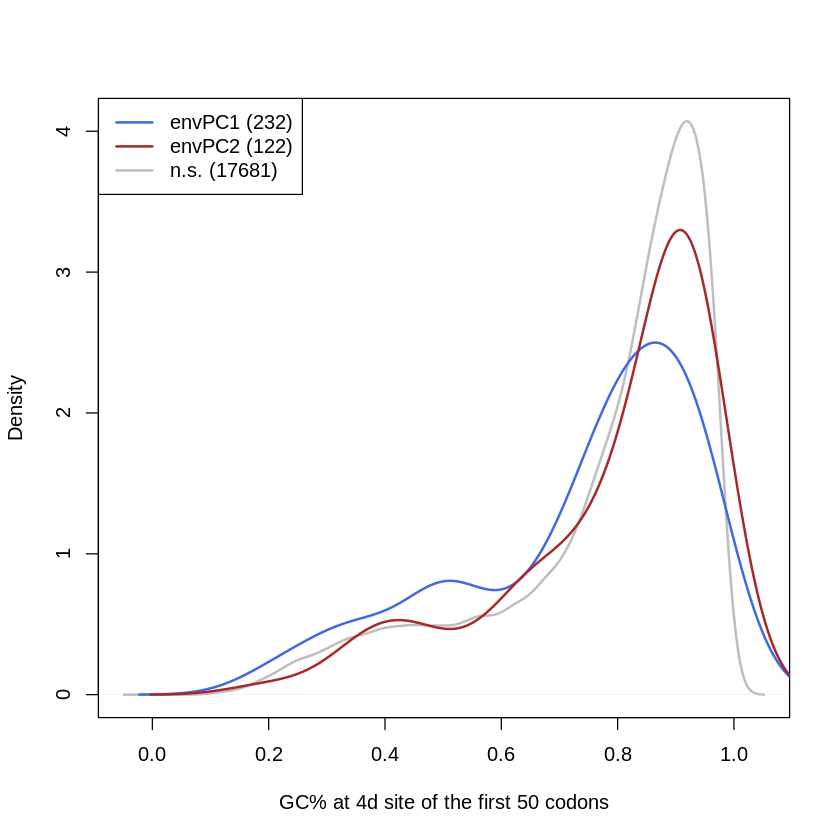

In [94]:
plot(density(gc.og.4d.50.avg[setdiff(testRes_envPC1_v2$OG,union(sigGeneEnvPC1,sigGeneEnvPC2))],na.rm = T),
     col = alpha("grey",1),lwd = 2,main = "",xlab = "GC% at 4d site of the first 50 codons")
lines(density(gc.og.4d.50.avg[sigGeneEnvPC1],na.rm = T),
      col = alpha("royalblue",1),lwd = 2)
lines(density(gc.og.4d.50.avg[sigGeneEnvPC2],na.rm = T),
      col = alpha("brown",1),lwd = 2)
legend("topleft",lty = 1, lwd = 2,col = c("royalblue","brown","grey"),
       legend = c("envPC1 (232)","envPC2 (122)","n.s. (17681)"))

In [96]:
sort(gc.og.4d.50.avg[sigGeneEnvPC1])

OG0011048 OG0013562 OG0020325 OG0027746 OG0001446 OG0022494 OG0013170 OG0008678 
0.1786064 0.2055074 0.2219019 0.2467469 0.2579320 0.2665302 0.3097156 0.3129501 
OG0013487 OG0022474 OG0003913 OG0017062 OG0013811 OG0001973 OG0002527 OG0005445 
0.3184642 0.3298120 0.3397544 0.3542233 0.3548267 0.3571624 0.3606379 0.3990771 
OG0006065 OG0017837 OG0020664 OG0014594 OG0020327 OG0011125 OG0004600 OG0010665 
0.4089075 0.4146615 0.4197239 0.4641760 0.4649742 0.4706701 0.4743249 0.4893252 
OG0012055 OG0004974 OG0009892 OG0017435 OG0005323 OG0015268 OG0020908 OG0001871 
0.4946921 0.4962337 0.4963738 0.5005836 0.5030769 0.5143105 0.5182694 0.5186925 
OG0020632 OG0009171 OG0009580 OG0006446 OG0020516 OG0002326 OG0014956 OG0009635 
0.5237822 0.5297937 0.5384696 0.5397198 0.5405450 0.5495147 0.5743591 0.6019192 
OG0014020 OG0017384 OG0024310 OG0021070 OG0007307 OG0013996 OG0023380 OG0011353 
0.6161122 0.6327638 0.6409453 0.6410863 0.6448618 0.6627033 0.6638990 0.6725456 
OG0011319 OG0010645 OG0023821 OG0019284 OG0004999 OG0001374 OG0006872 OG0011145 
0.6806091 0.6818260 0.6914667 0.6975083 0.6981106 0.7050588 0.7052442 0.7234159 
OG0012917 OG0017040 OG0021573 OG0017395 OG0018915 OG0026854 OG0001632 OG0013137 
0.7378896 0.7434465 0.7448925 0.7450141 0.7452432 0.7456483 0.7536268 0.7561144 
OG0016796 OG0014896 OG0006907 OG0013785 OG0018950 OG0025908 OG0012734 OG0015016 
0.7563638 0.7605722 0.7613417 0.7677268 0.7688641 0.7694280 0.7700822 0.7717055 
OG0016631 OG0019808 OG0006299 OG0009596 OG0009654 OG0030526 OG0004860 OG0016821 
0.7790227 0.7843570 0.7849100 0.7879647 0.7887299 0.7910479 0.7922525 0.7969986 
OG0004081 OG0010343 OG0016595 OG0001315 OG0012099 OG0010299 OG0001226 OG0012377 
0.7973979 0.8019562 0.8047794 0.8070401 0.8074862 0.8081894 0.8090153 0.8123953 
OG0002267 OG0006169 OG0017092 OG0009497 OG0006454 OG0014342 OG0006462 OG0019946 
0.8169261 0.8189204 0.8214813 0.8285956 0.8331814 0.8336338 0.8339737 0.8351112 
OG0012463 OG0000617 OG0008313 OG0001399 OG0001269 OG0006497 OG0015045 OG0015981 
0.8403585 0.8408888 0.8431505 0.8440283 0.8445512 0.8462250 0.8472107 0.8544162 
OG0009066 OG0010727 OG0013325 OG0013595 OG0027084 OG0015031 OG0001181 OG0003856 
0.8557492 0.8633866 0.8635485 0.8666051 0.8691664 0.8699450 0.8733599 0.8798777 
OG0004079 OG0023330 OG0006053 OG0010826 OG0004523 OG0002170 OG0009770 OG0017878 
0.8804006 0.8836402 0.8846749 0.8869432 0.8896242 0.8899471 0.8926156 0.8930201 
OG0015449 OG0014032 OG0015403 OG0007335 OG0012523 OG0015194 OG0014615 OG0017512 
0.8930422 0.8939798 0.8943975 0.8961748 0.9007868 0.9016488 0.9040973 0.9048263 
OG0011728 OG0010189 OG0013027 OG0015402 OG0009036 OG0011342 OG0002631 OG0009547 
0.9056832 0.9106360 0.9111083 0.9202904 0.9215402 0.9243130 0.9254126 0.9255032 
OG0014903 OG0002585 OG0016485 OG0003010 OG0014335 OG0010543 OG0005670 OG0011444 
0.9302037 0.9303071 0.9311626 0.9324486 0.9356922 0.9365301 0.9455596 0.9459300 
OG0020521 OG0006555 OG0009172 OG0024341 OG0012793 OG0005022 OG0012424 OG0003863 
0.9475826 0.9485412 0.9505700 0.9508527 0.9585429 0.9607869 0.9615566 0.9638226 
OG0007248 OG0028548 OG0007325 OG0015751 OG0008112 OG0003084 OG0002889 OG0008555 
0.9710363 0.9713752 0.9718147 0.9726128 0.9765371 0.9767313 0.9769804 0.9774397

In [99]:
dnaFastaPerOG["OG0013562"]

$OG0013562
DNAStringSet object of length 945:
      width seq                                             names               
  [1]  1953 CCAGCTCC---AGTAAGTAAGA...ATACCGCACCTGCAGATCTTAG OG0013562:10wheat...
  [2]  1953 CCAGCCCC---AGTAAGTAAGA...ATACCGCACCTGCAGATCTTAG OG0013562:10wheat...
  [3]  1953 CCAGCTCC---AGTAAGTAAGA...ATACCGCACCTGCAGATCTTAG OG0013562:10wheat...
  [4]  1953 CCAGCTCC---AGTAAGTAAGA...ATACCGCACCTGCAGATCTTAG OG0013562:10wheat...
  [5]  1953 CCAGCCCC---AGTAAGTAAGA...ATACCGCACCTGCAGATCTTAG OG0013562:10wheat...
  ...   ... ...
[941]  1953 CCAACTCC---AGGAGGGGAGA...ATACCGCACCTGCAGGTCGTAG OG0013562:lpTucGr...
[942]  1953 CCAACTCC---AGGAGGGGAGA...ATACCGCACCTGCAGGTCGTAG OG0013562:lpTucGr...
[943]  1953 CCAACTCT---AGGAGGTAAGA...ATACCGCACCTGCAGGTCTTAG OG0013562:mabambo...
[944]  1953 CCAACTCT---AGGAGGTAAGA...ATACCGCACCTGCAGGTCTTAG OG0013562:mabambo...
[945]  1953 CCAACTCC---AGGAGAGAAGA...ATACCGCACCTGCAGGTCTTAG OG0013562:pearl_m...
